In [1]:
# %pip install torch torchvision numpy matplotlib seaborn scikit-learn
import copy
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.datasets import fetch_olivetti_faces
from torch import nn
from torchvision.transforms import v2

SEED = 69
STEPS = 3000
BATCH_SIZE = 64
STEP_RECORD = 200
TRAIN_SIZE = 300
N_LAYERS = 8
HIDDEN = 512
LR = 2e-4

torch.manual_seed(SEED)
torch.set_num_threads(2)  # Для маленьких MLP на CPU.
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
print(f"PyTorch {torch.__version__} | CPU | seed={SEED}")

# Images
IMG = (64, 64)

data = fetch_olivetti_faces(shuffle=True, random_state=SEED)
X = torch.tensor(data.data.reshape((400, 1, 64, 64)))
X_resized = X.squeeze(1)

augment = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomResizedCrop(IMG, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
    v2.ColorJitter(brightness=0.1, contrast=0.1),
])


def augment_batch(images):
    augmented = []
    for image in images:
        augmented.append(augment(image))
    batch = torch.stack(augmented)
    return batch.flatten(1).clamp(0, 1)


def dequantize(x):
    return x + torch.rand_like(x) / 256

PyTorch 2.11.0+cu130 | CPU | seed=69


In [2]:
from matplotlib.colors import LinearSegmentedColormap

# Делаем кастомную цветовую гамму
not_human_cmap = LinearSegmentedColormap.from_list(
    "not_human",
    [
        (0.000, "#010502"),
        (0.107, "#022112"),
        (0.230, "#04402a"),
        (0.357, "#046141"),
        (0.463, "#047a6e"),
        (0.532, "#048a90"),
        (0.618, "#039faf"),
        (0.751, "#0ac0c3"),
        (0.868, "#06dfdd"),
        (1.000, "#58eaeb"),
    ]
)

def print_img(pixels: np.ndarray[np.float64], cmap=not_human_cmap):
    plt.figure()
    sns.heatmap(
        pixels.reshape(IMG),
        cmap=cmap,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
    )

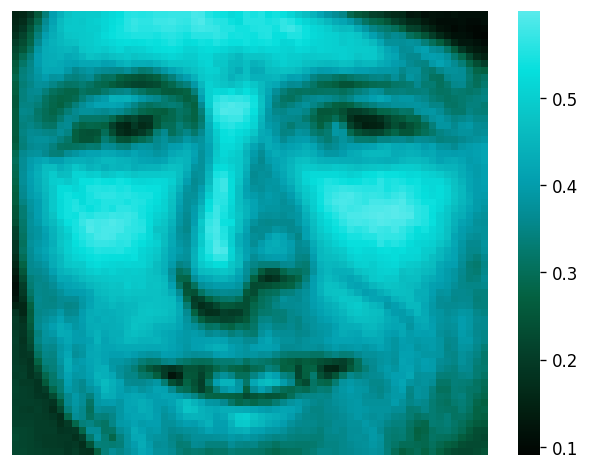

In [3]:
print_img(X_resized[67])

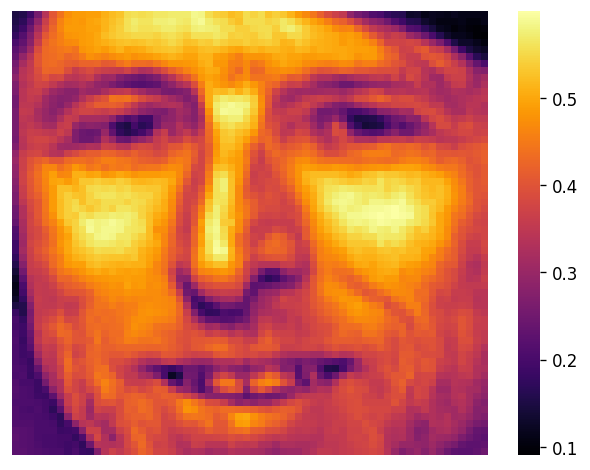

In [4]:
print_img(X_resized[67], cmap="inferno")

## 2. Обратимые слои

**Аддитивный coupling (NICE):** $y_1=x_1$, $y_2=x_2+m_\theta(x_1)$.
Обратный ход: $x_2=y_2-m_\theta(y_1)$, якобиан треугольный с единицами на диагонали: $\log|\det J|=0$.

**Аффинный coupling (RealNVP):** $y_1=x_1$, $y_2=x_2\odot e^{s_\theta(x_1)}+t_\theta(x_1)$.
Обратный ход: $x_2=\big(y_2-t_\theta(y_1)\big)\odot e^{-s_\theta(y_1)}$, обращать MLP по-прежнему не нужно.
Якобиан тоже треугольный, но теперь $\log|\det J|=\sum_j s_{\theta,j}(x_1)$.
Масштаб зависит от содержимого картинки, поэтому модель может уменьшать разброс там, где изображение гладкое, — именно это и убирает зернистость.
Для устойчивости $s$ пропускаем через $\tanh$.

Чередуем неизменяемую половину в восьми слоях и в конце добавляем общий обучаемый масштаб:

$$z=f_\theta(x)=e^{s}\odot g_\theta(x),\qquad
\log|\det J_f(x)|=\sum_{j=1}^{D}s_j+\sum_{\ell}\log|\det J_\ell(x)|,\qquad D=32\cdot 32.$$

При $p_Z=\mathcal N(0,I_D)$ формула замены переменных даёт

$$\log p_\theta(x)=-\tfrac12\sum_{j=1}^{D}(z_j^2+\log 2\pi)+\log|\det J_f(x)|.$$

Минимизируем среднюю **NLL**: $-\log p_\theta(x)$; единицы — нат на изображение.

In [5]:
class AffineCoupling(nn.Module):
    def __init__(self, keep, n, hidden_features=256):
        super().__init__()
        self.keep = keep
        n_from = (n + 1 - keep) // 2
        self.n_to = n - n_from

        self.net = nn.Sequential(nn.Linear(n_from, hidden_features), nn.Tanh(),
                                 nn.Linear(hidden_features, hidden_features), nn.Tanh(),
                                 nn.Linear(hidden_features, 2 * self.n_to))
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x, inverse=False):
        x_fixed = x[:, self.keep::2]
        x_changed = x[:, 1 - self.keep::2]

        net_output = self.net(x_fixed)
        log_scale = torch.tanh(net_output[:, :self.n_to])
        shift = net_output[:, self.n_to:]

        y = x.clone()
        if inverse:
            y[:, 1 - self.keep::2] = (x_changed - shift) * torch.exp(-log_scale)
            return y, -log_scale.sum(dim=1)

        y[:, 1 - self.keep::2] = x_changed * torch.exp(log_scale) + shift
        return y, log_scale.sum(dim=1)


class NICE(nn.Module):
    def __init__(self, n, layers=8, hidden_features=100):
        super().__init__()
        self.n = n
        self.layers = nn.ModuleList([
            AffineCoupling(i % 2, n, hidden_features) for i in range(layers)
        ])
        self.log_scale = nn.Parameter(torch.zeros(n))

    def forward(self, x):
        log_det = self.log_scale.sum()
        for layer in self.layers:
            x, layer_log_det = layer(x)
            log_det = log_det + layer_log_det
        z = x * self.log_scale.exp()
        return z, log_det

    def inverse(self, z):
        x = z * (-self.log_scale).exp()
        for layer in reversed(self.layers):
            x, _ = layer(x, inverse=True)
        return x

    def log_prob(self, x):
        z, log_det = self(x)
        # log_base = -0.5 * (z.square() + math.log(2 * math.pi)).sum(dim=1)
        log_base = (-z - 2 * F.softplus(-z)).sum(dim=1)
        return log_base + log_det

    @torch.no_grad()
    def sample(self, batch_size, temperature=1.0):
        # z = temperature * torch.randn(batch_size, self.n)
        z = temperature * torch.logit(torch.rand(batch_size, self.n), eps=1e-6)
        return self.inverse(z)


model = NICE(IMG[0] * IMG[1], layers=N_LAYERS, hidden_features=HIDDEN)

In [6]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params}")

Total params: 27308032


## 3. Обучение максимальным правдоподобием

AdamW обновляет MLP (с weight decay) и общий масштаб (без него), скорость обучения плавно падает по косинусу.
На каждом шаге батч заново аугментируется и деквантуется.
Проверочная выборка используется только для наблюдения за качеством и чтобы в конце взять лучшую по ней модель. Сравним NLL до и после обучения: меньше — лучше.

(200, -5274.76611328125, -5152.9951171875)
(400, -6241.60107421875, -6018.9501953125)
(600, -6789.611328125, -6486.81103515625)
(800, -7253.52490234375, -6828.20068359375)
(1000, -7602.37646484375, -7035.01318359375)
(1200, -7862.732421875, -7234.7216796875)
(1400, -8165.3984375, -7444.66552734375)
(1600, -8290.9833984375, -7464.55615234375)
(1800, -8484.84375, -7519.7841796875)
(2000, -8656.6904296875, -7679.42138671875)
(2200, -8788.1875, -7749.65380859375)
(2400, -8915.76953125, -7765.5908203125)
(2600, -9036.81640625, -7792.00927734375)
(2800, -9196.6220703125, -7907.27880859375)
(3000, -9259.48046875, -7890.87646484375)
Обучение: 1219.4 с; 3000 шагов
NLL (val): 20281.982 -> -7907.279 нат/изображение (лучший шаг 2800)


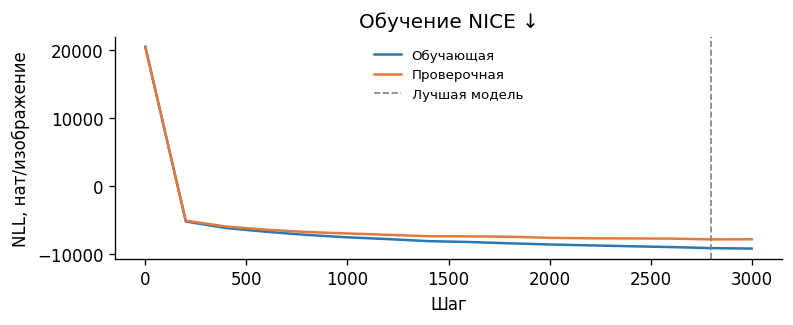

In [7]:
train_images = X[:TRAIN_SIZE]
x_train = X_resized[:TRAIN_SIZE].flatten(1)
x_val = X_resized[TRAIN_SIZE:].flatten(1)

x_train_eval = dequantize(x_train)
x_val_eval = dequantize(x_val)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
history = []

@torch.no_grad()
def record(step):
    history.append((step, -model.log_prob(x_train_eval).mean().item(),
                         -model.log_prob(x_val_eval).mean().item()))

# Ставим масштабы сразу примерно правильными
with torch.no_grad():
      #  model.log_scale.copy_(-x_train.std(0).clamp_min(1e-3).log())
       model.log_scale.copy_(math.log(math.pi / math.sqrt(3)) - x_train.std(0).clamp_min(1e-3).log())

record(0)
best_val_nll = history[0][2]
best_step = 0
best_state = copy.deepcopy(model.state_dict())

started = time.perf_counter()
model.train()
for step in range(1, STEPS + 1):
    indices = torch.randint(TRAIN_SIZE, (BATCH_SIZE,))
    batch = augment_batch(train_images[indices])
    batch = dequantize(batch)

    loss = -model.log_prob(batch).mean()
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()

    if step % STEP_RECORD == 0:
        record(step)
        print(history[-1])
        val_nll = history[-1][2]
        if val_nll < best_val_nll:
            best_val_nll = val_nll
            best_step = step
            best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)
model.eval()

print(f"Обучение: {time.perf_counter() - started:.1f} с; {STEPS} шагов")
print(f"NLL (val): {history[0][2]:.3f} -> {best_val_nll:.3f} нат/изображение (лучший шаг {best_step})")

h = np.array(history)
fig, ax = plt.subplots(figsize=(6.5, 2.6), layout="constrained")
ax.plot(h[:, 0], h[:, 1], label="Обучающая", color="#2878B5")
ax.plot(h[:, 0], h[:, 2], label="Проверочная", color="#E07A3F")
ax.axvline(best_step, color="gray", linestyle="--", linewidth=1, label="Лучшая модель")
ax.set(xlabel="Шаг", ylabel="NLL, нат/изображение", title="Обучение NICE ↓")
ax.legend(frameon=False, fontsize=8)
plt.show()

In [8]:
def print_imgs(images, ncols=5, size=1.6, cmap=not_human_cmap, vmin=None, vmax=None):
    images = [img.detach().cpu().numpy().reshape(IMG) for img in images]
    nrows = math.ceil(len(images) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, img in zip(np.ravel(axes), images):
        sns.heatmap(img, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False,
                    xticklabels=False, yticklabels=False, square=True)
    plt.tight_layout()
    plt.show()


In [ ]:
from google.colab import files

torch.save(model.state_dict(), "nice_weights.pt")
files.download("nice_weights.pt")

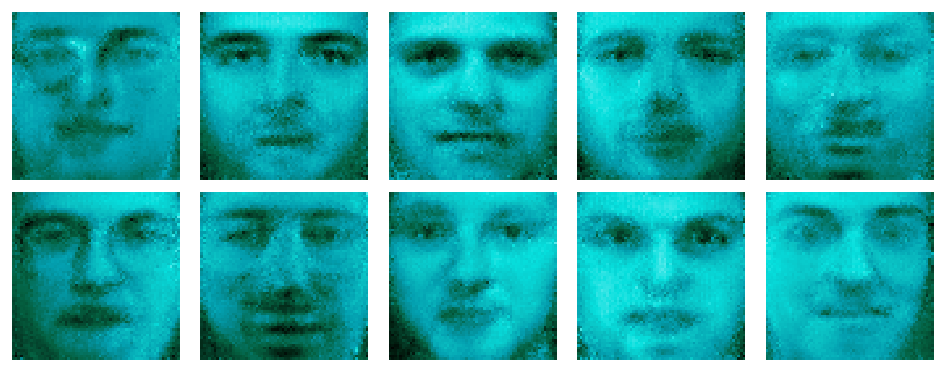

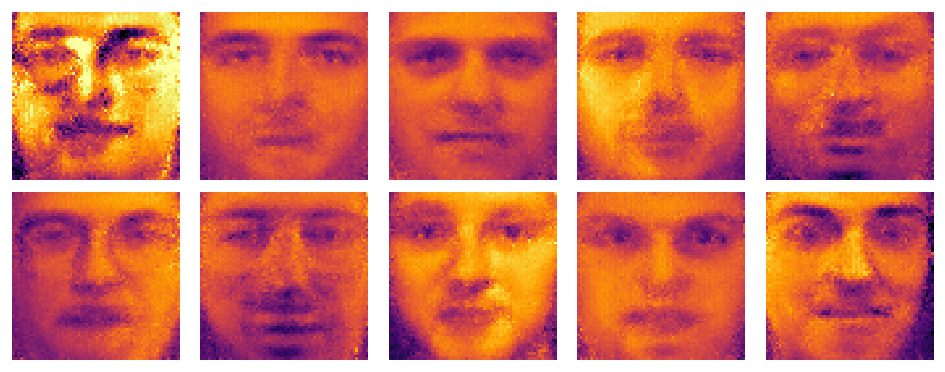

In [ ]:
TEMPERATURE = 0.97

with torch.no_grad():
    # сдвигаем их ближе к нулю чтобы более вероятные(более реальные) картинки генерились
    generated = model.sample(10, temperature=TEMPERATURE)

print_imgs(generated)
print_imgs(generated.clamp(0, 1), cmap="inferno", vmin=0, vmax=1)